# Behaviour Cloning Evaluation

In [1]:
import sys
import os
import torch
import pandas as pd

if 'google.colab' in sys.modules:
  from google.colab import drive
  drive.mount( "/content/drive")
  if os.path.isdir('drive/MyDrive/Projects/Offline_RL_BSc_Thesis/notebooks'):
    os.chdir('drive/MyDrive/Projects/Offline_RL_BSc_Thesis/notebooks')


project_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), "../../"))
if project_root not in sys.path:
    sys.path.append(project_root)

torch_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

norm_names = ['raw', 'max_abs', 'min_max', 'robust', 'standard']
selected_features = [
    'X', 'Y', 'lv_X', 'lv_Y',
    'reward', 'angle', 'angular_velocity',
    'leg_1', 'leg_2'
]

## Test Evaluation

In [2]:
from src.utils.evaluation import evaluate_BC_models_on_test_dataset


plots_dir = "/plots"
os.makedirs(plots_dir, exist_ok=True)

C:\Users\Miro\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Replay Buffer

----------------------------------------------------------------------------------------------------

Evaluating normalization: raw
----------------------------------------------------------------------------------------------------

Evaluating normalization: max_abs
----------------------------------------------------------------------------------------------------

Evaluating normalization: min_max
----------------------------------------------------------------------------------------------------

Evaluating normalization: robust
----------------------------------------------------------------------------------------------------

Evaluating normalization: standard


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
normalization,,,,,,,,
standard,0.576025,0.563999,0.495148,0.563999,0.505417,0.653156,0.576025,0.598753
min_max,0.574466,0.563057,0.494406,0.563057,0.504390,0.654794,0.574466,0.597932
robust,0.574054,0.562574,0.493618,0.562574,0.503226,0.654094,0.574054,0.597340
raw,0.567437,0.562155,0.490880,0.562155,0.500152,0.652066,0.567437,0.591356
max_abs,0.573270,0.561796,0.492835,0.561796,0.503727,0.652182,0.573270,0.596198


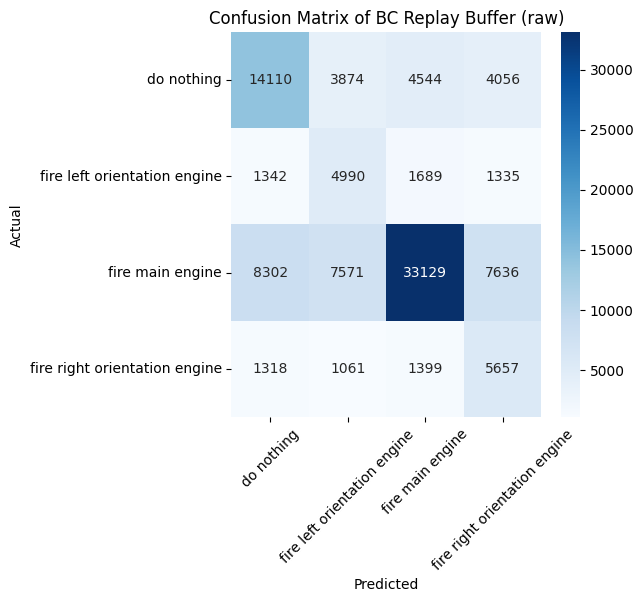

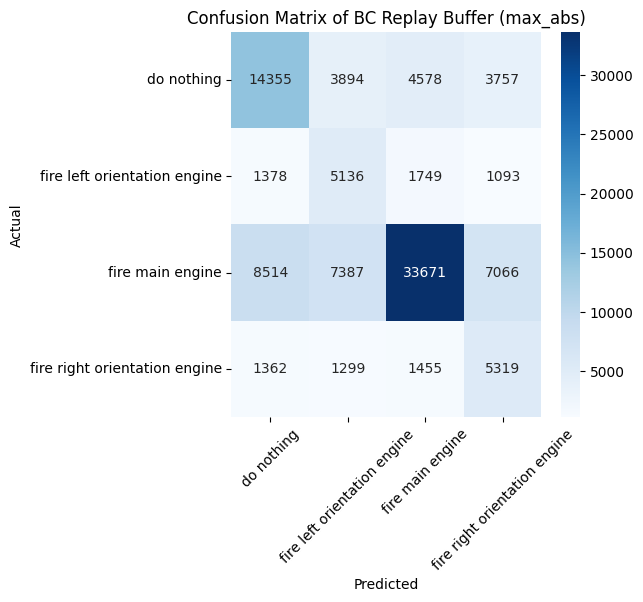

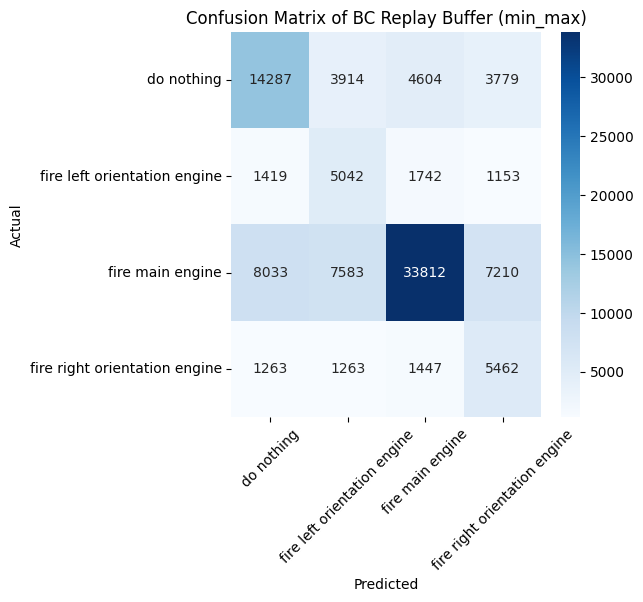

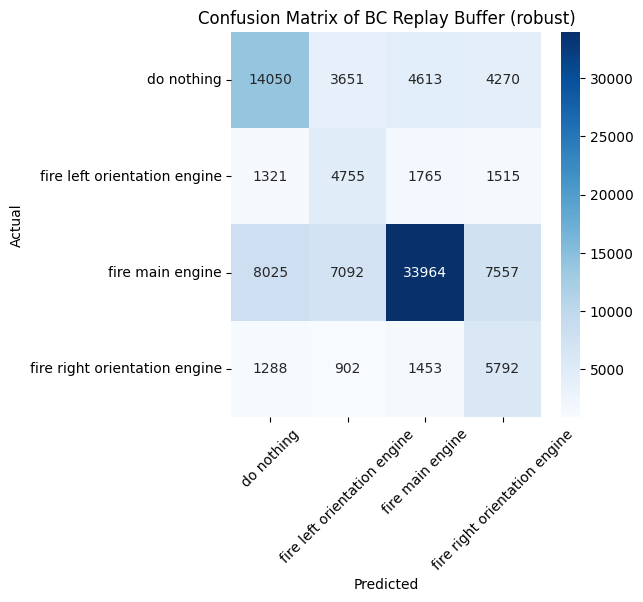

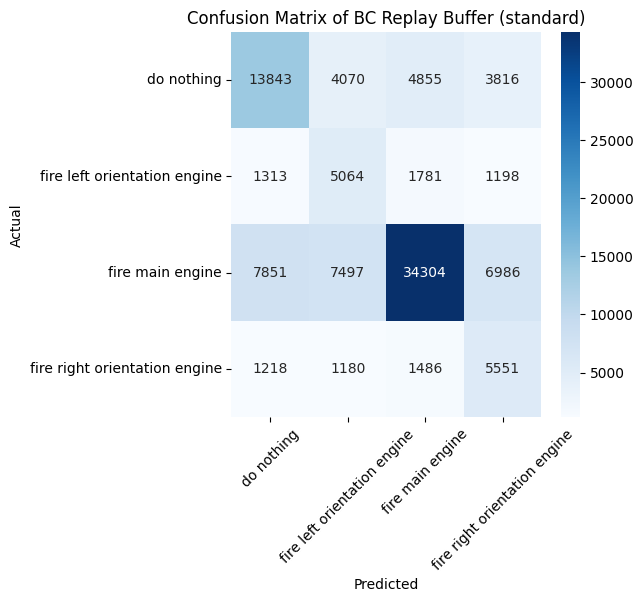

In [3]:
rb_summary = evaluate_BC_models_on_test_dataset(
    dataset_type='replay_buffer',
    norm_names=norm_names,
    selected_features=selected_features,
    plots_dir=plots_dir,
    torch_device=torch_device,
)
rb_summary

### Final Policy

----------------------------------------------------------------------------------------------------

Evaluating normalization: raw
----------------------------------------------------------------------------------------------------

Evaluating normalization: max_abs
----------------------------------------------------------------------------------------------------

Evaluating normalization: min_max
----------------------------------------------------------------------------------------------------

Evaluating normalization: robust
----------------------------------------------------------------------------------------------------

Evaluating normalization: standard


,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
normalization,,,,,,,,
raw,0.979490,0.984203,0.942931,0.984203,0.962317,0.980649,0.979490,0.979753
min_max,0.979621,0.983936,0.943568,0.983936,0.962589,0.980752,0.979621,0.979885
max_abs,0.976301,0.983179,0.928915,0.983179,0.953885,0.978380,0.976301,0.976782
standard,0.975524,0.980054,0.931584,0.980054,0.954080,0.977215,0.975524,0.975926
robust,0.968569,0.979484,0.906922,0.979484,0.939163,0.972472,0.968569,0.969470


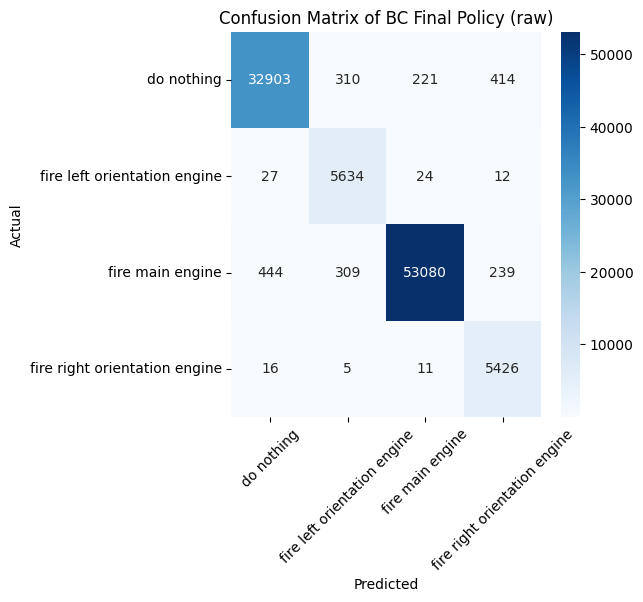

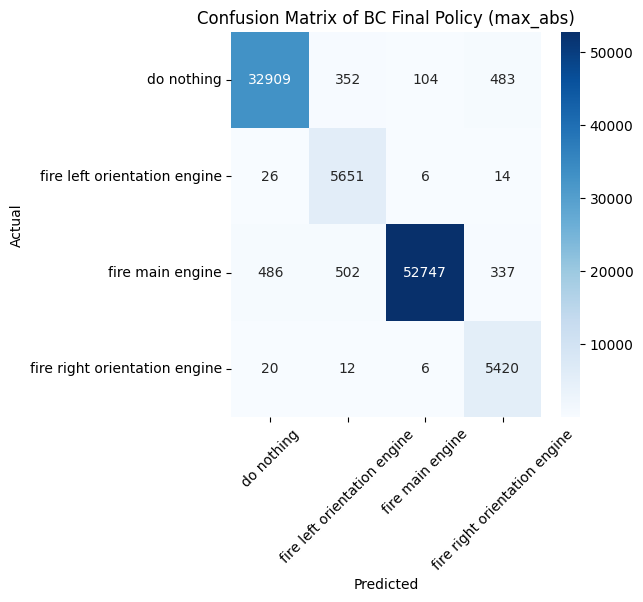

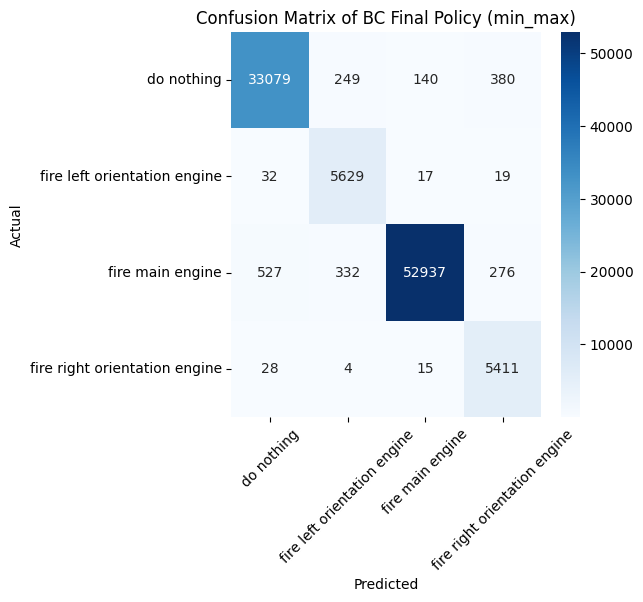

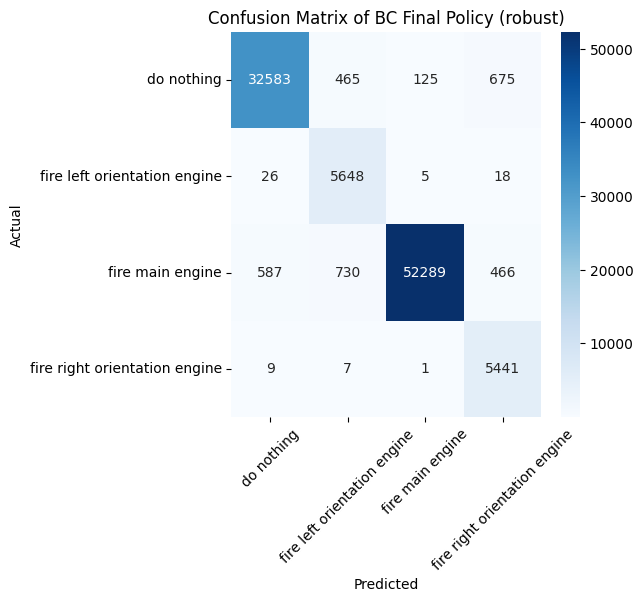

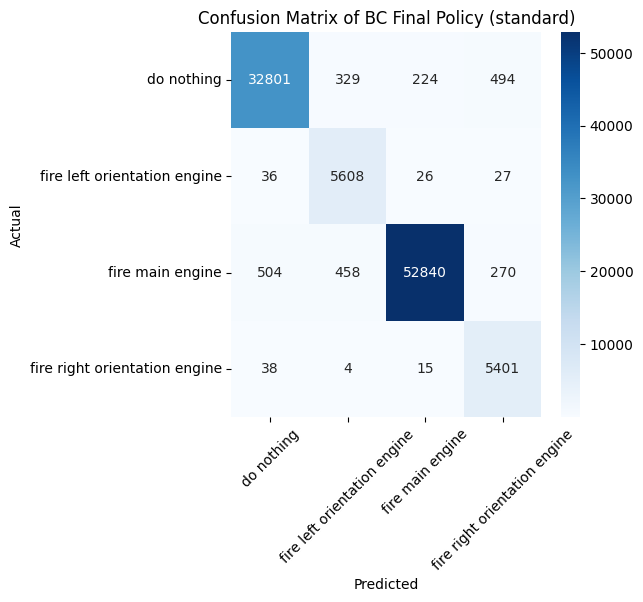

In [4]:
fp_summary = evaluate_BC_models_on_test_dataset(
    dataset_type='final_policy',
    norm_names=norm_names,
    selected_features=selected_features,
    plots_dir=plots_dir,
    torch_device=torch_device,
)
fp_summary

## Evaluation in the Live Environment for 1000 episodes

In [5]:
import yaml
import warnings

from src.utils.live_env_testing import BC_evaluate_model_in_live_env

warnings.filterwarnings("ignore")
with open('../../config/BC/bc_live_env_elavuation_config.yaml', 'r') as f:
    bc_live_env_config_config = yaml.safe_load(f)

### Replay Buffer

In [6]:
rb_rewards_dict = {}

for rb_norm_name in norm_names:
    print('-'*100)
    print('Normalization:', rb_norm_name)

    if rb_norm_name != 'raw':
        rb_normalization_technique = torch.jit.load(f'../../models/BC/replay_buffer/normalization/{rb_norm_name}_normalization.pt')
    else:
        rb_normalization_technique = None
    rb_model = torch.jit.load(f'../../models/BC/replay_buffer/BC_{rb_norm_name}.pt')

    rb_rewards = BC_evaluate_model_in_live_env(
        env_test_params=bc_live_env_config_config,
        model_name='replay_buffer',
        model_variant_name=rb_norm_name,
        norm_technique=rb_normalization_technique,
        model = rb_model,
    )
    rb_rewards_dict[f'{rb_norm_name}_reward'] = rb_rewards

----------------------------------------------------------------------------------------------------
Normalization: raw


100%|██████████| 1000/1000 [06:52<00:00,  2.43it/s]


----------------------------------------------------------------------------------------------------
Normalization: max_abs


100%|██████████| 1000/1000 [06:26<00:00,  2.59it/s]


----------------------------------------------------------------------------------------------------
Normalization: min_max


100%|██████████| 1000/1000 [04:49<00:00,  3.46it/s]


----------------------------------------------------------------------------------------------------
Normalization: robust


100%|██████████| 1000/1000 [05:26<00:00,  3.07it/s]


----------------------------------------------------------------------------------------------------
Normalization: standard


100%|██████████| 1000/1000 [05:21<00:00,  3.11it/s]


### Final Policy

In [8]:
fp_rewards_dict = {}

for fp_norm_name in norm_names:
    print('-'*100)
    print('Normalization:', fp_norm_name)

    if fp_norm_name != 'raw':
        fp_normalization_technique = torch.jit.load(f'../../models/BC/final_policy/normalization/{fp_norm_name}_normalization.pt')
    else:
        fp_normalization_technique = None
    fp_model = torch.jit.load(f'../../models/BC/final_policy/BC_{fp_norm_name}.pt')

    fp_rewards = BC_evaluate_model_in_live_env(
        env_test_params=bc_live_env_config_config,
        model_name='final_policy',
        model_variant_name=fp_norm_name,
        norm_technique=fp_normalization_technique,
        model = fp_model,
    )
    fp_rewards_dict[f'{fp_norm_name}_reward'] = fp_rewards

----------------------------------------------------------------------------------------------------
Normalization: raw


100%|██████████| 1000/1000 [05:29<00:00,  3.03it/s]


----------------------------------------------------------------------------------------------------
Normalization: max_abs


100%|██████████| 1000/1000 [07:18<00:00,  2.28it/s]


----------------------------------------------------------------------------------------------------
Normalization: min_max


100%|██████████| 1000/1000 [05:16<00:00,  3.16it/s]


----------------------------------------------------------------------------------------------------
Normalization: robust


100%|██████████| 1000/1000 [05:58<00:00,  2.79it/s]


----------------------------------------------------------------------------------------------------
Normalization: standard


100%|██████████| 1000/1000 [07:07<00:00,  2.34it/s]
